In [2]:
#### 1. Installing and importing libraries
# conda install conda-forge::scikit-learn
# conda install pandas
# conda install conda-forge::geopandas
# pip install pykrige (for the spatial interpolation), scikit-learn (NN and CV), numpy, and pandas
# pip install numpy pandas matplotlib scikit-learn pykrige statsmodels
# conda install -c anaconda statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pykrige.ok import OrdinaryKriging
# To ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [3]:
# 2. Loading the dataset
data = pd.read_csv('E:/VData/SData/Wells3.csv')

In [4]:
seed = 42

In [5]:
data.head()

,x_coord,y_coord,Depth,pH,SO4,NO3,T
0,17.23,15.57,201.00,6.00,825.0,24.0,27.0
1,17.48,15.83,220.00,6.00,925.0,5.0,27.0
2,16.83,14.17,38.88,6.22,13.0,7.0,28.8
3,16.95,14.43,35.90,6.39,11.0,6.0,25.0
4,16.48,13.25,53.00,6.40,2.5,1.2,30.7


In [8]:
# 3. data preparation

In [6]:
# Target: Wells pH 
y = data['NO3'].values  

In [7]:
# The feature variables
X_features = data[['T', 'Depth']].values

In [8]:
# Spatial coordinates (X, Y)
X_coords = data[['x_coord', 'y_coord']].values

In [9]:
# Splitting the dataset into training and testing dataset
X_f_train, X_f_test, X_c_train, X_c_test, y_train, y_test = train_test_split(X_coords, X_features, y, test_size = 0.3, random_state = 42)

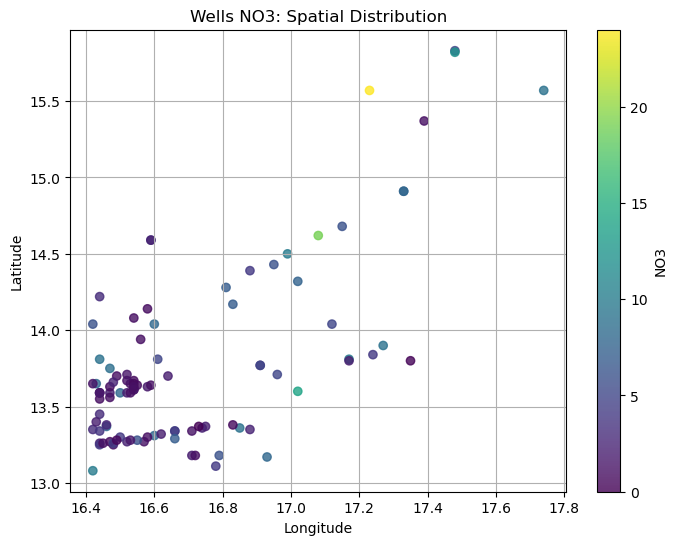

In [12]:
# 4. Data Exploration: Visualising spatial distribution of wells pH
plt.figure(figsize = (8, 6))
scatter = plt.scatter(data['x_coord'], data['y_coord'], c = data['NO3'], cmap ='viridis', alpha = 0.8)
plt.colorbar(scatter, label = 'NO3')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wells NO3: Spatial Distribution')
plt.grid(True)
plt.show()


In [14]:
###############  STEP 1: TRAINING THE REGRESSION MODEL AND COMPUTING THE RESIDUALS ##################

In [15]:
#### 5. Training the Regression model and Calculating Residuals

In [13]:
# a. Fitting LR model on  features
lr = LinearRegression()
lr.fit(X_f_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Predicting deterministic trend
y_pred_train = lr.predict(X_f_train) # Predicting on the training data
y_pred_test = lr.predict(X_f_test) # Predicting on the testing data

In [15]:
# b. Compute residuals (y_true - y_pred)
residuals_train = y_train - y_pred_train # Training residuals
residuals_test = y_test - y_pred_test    # Testing residuals

In [19]:
####################### STEP 2: PERFORMING THE ORDINARY KRIGING ON RESIDUALS ########################

In [20]:
##### 6. Performing Ordinary Kriging on Residuals

In [16]:
# a. Fit Ordinary Kriging on spatial coordinates and residuals
OK = OrdinaryKriging(
    x = X_c_train[:, 0],  # Longitude
    y = X_c_train[:, 1],  # Latitude
    z = residuals_train,
    variogram_model = 'gaussian',  # Run the krige CV to know thw best parameters based on your dataset, X, and ) Options are: 'linear', 'power', 'gaussian', 'spherical', 'exponential'
    verbose = False,
    enable_plotting = False
)

In [17]:
# b. Predicting residual correction for the test coordinates
kriged_residuals_test, kriged_variance = OK.execute('points', X_c_test[:, 0], X_c_test[:, 1])

In [18]:
# c. Final Prediction = Deterministic Trend + Spatial Residual Prediction
y_pred_rk = y_pred_test + kriged_residuals_test

In [36]:
############## EVALUATING THE MODEL PERFORMANCE ################################

In [37]:
##### 7. Evaluate Model Performance: Compare standard Linear Regression against Regression Kriging:

In [19]:
# a. Metrics for Pure L Regression
r2_lr = r2_score(y_test, y_pred_test) # LR Rsq 
mse_lr = mean_squared_error(y_test, y_pred_test) # LR MSE

In [20]:
# b. Metrics for Regression Kriging
r2_rk = r2_score(y_test, y_pred_rk) # RK Rsq
mse_rk = mean_squared_error(y_test, y_pred_rk) # RK MSE

In [21]:
# c. Comparison Table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Regression Kriging'],
    'R2 Score': [r2_lr, r2_rk],
    'MSE': [mse_lr, mse_rk],
})

In [22]:
# Printing the table
print(results)

                Model  R2 Score        MSE
0   Linear Regression  0.045384  26.047447
1  Regression Kriging  0.062189  25.588926


In [42]:
######################### CREATING A SPATIAL GRID SURFACE INTERPOLATION #############$

In [43]:
########### 8. Create Spatial Grid Surface Interpolation
### Generating a continuous prediction surface over the region grid:

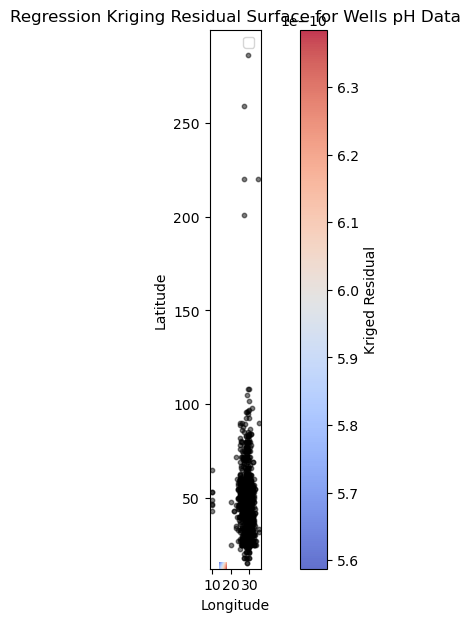

In [44]:
grid_x = np.linspace(data['x_coord'].min(), data['x_coord'].max(), 100)
grid_y = np.linspace(data['y_coord'].min(), data['y_coord'].max(), 100)

# Krige residual surface across grid
grid_residuals, _ = OK.execute('grid', grid_x, grid_y)

# Plot interpolated spatial residual map
plt.figure(figsize = (10, 7))
plt.imshow(
    grid_residuals, 
    extent = [grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()], 
    origin = 'lower', 
    cmap = 'coolwarm', 
    alpha = 0.8
)
plt.colorbar(label = 'Kriged Residual')
plt.scatter(X_c_train[:, 0], X_c_train[:, 1], c = 'black', s = 10, alpha = 0.5)
plt.title('Regression Kriging Residual Surface for Wells NO3 Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()
